In [ ]:
# ==========================================
# 0. Imports
# ==========================================
import os
import json
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_from_disk
from sklearn.metrics import confusion_matrix, classification_report
from transformers import AutoModelForAudioClassification, Trainer, TrainingArguments, Wav2Vec2Processor


In [ ]:
# ==========================================
# 1. Directory Setup
# ==========================================

out_dir = Path("/content/drive/MyDrive/Colab022Notebooks/GP/ModelExp")
arrow_save_dir = out_dir / "_Arrow_Datasets"
results_dir = out_dir / "_Master_Grid_Search_Results"
csv_path = results_dir / "final_grid_search_report.csv"

# datasets we working on
DATASETS = ["CREMA-D","EYASE","TESS","BAVED"]


📊 Generating Final Report for: CREMA-D
🏆 Best Model Found: wav2vec2-base
⚙️ Config: LR=5e-05 | Batch Size=8
📈 Validation Accuracy: 0.7784

⏳ Loading Data and Model...


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

🔮 Running Predictions on Test Set...


📸 Confusion Matrix saved to: /content/drive/MyDrive/Colab022Notebooks/GP/ModelExp/_Plots/CREMA-D_Confusion_Matrix.png


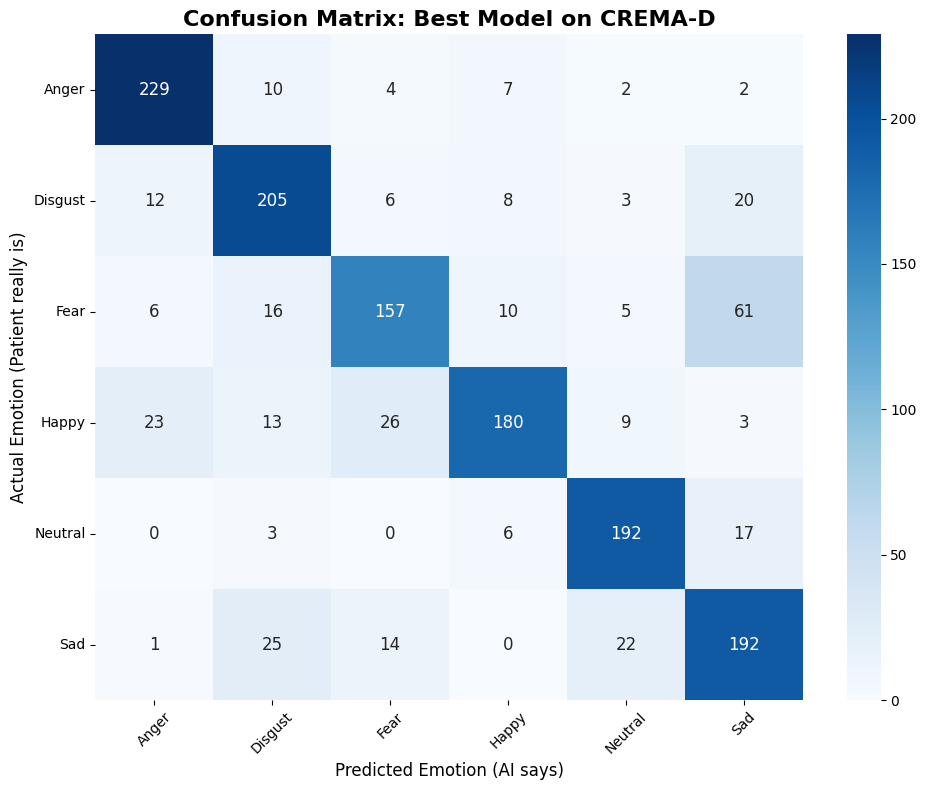


📋 CLINICAL CLASSIFICATION REPORT: CREMA-D
              precision    recall  f1-score   support

       Anger       0.85      0.90      0.87       254
     Disgust       0.75      0.81      0.78       254
        Fear       0.76      0.62      0.68       255
       Happy       0.85      0.71      0.77       254
     Neutral       0.82      0.88      0.85       218
         Sad       0.65      0.76      0.70       254

    accuracy                           0.78      1489
   macro avg       0.78      0.78      0.78      1489
weighted avg       0.78      0.78      0.77      1489

📊 Generating Final Report for: EYASE
🏆 Best Model Found: wav2vec2-base
⚙️ Config: LR=5e-05 | Batch Size=8
📈 Validation Accuracy: 0.8023

⏳ Loading Data and Model...


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

🔮 Running Predictions on Test Set...


📸 Confusion Matrix saved to: /content/drive/MyDrive/Colab022Notebooks/GP/ModelExp/_Plots/EYASE_Confusion_Matrix.png


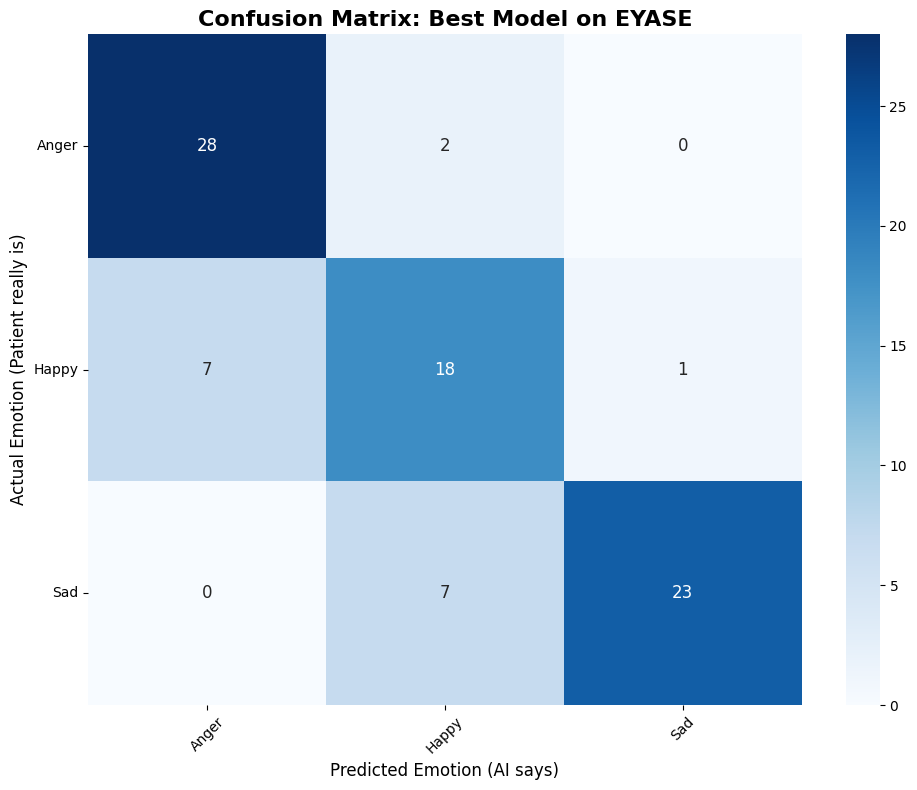


📋 CLINICAL CLASSIFICATION REPORT: EYASE
              precision    recall  f1-score   support

       Anger       0.80      0.93      0.86        30
       Happy       0.67      0.69      0.68        26
         Sad       0.96      0.77      0.85        30

    accuracy                           0.80        86
   macro avg       0.81      0.80      0.80        86
weighted avg       0.81      0.80      0.80        86

📊 Generating Final Report for: TESS
🏆 Best Model Found: wav2vec2-base
⚙️ Config: LR=3e-05 | Batch Size=8
📈 Validation Accuracy: 1.0000

⏳ Loading Data and Model...


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

🔮 Running Predictions on Test Set...


📸 Confusion Matrix saved to: /content/drive/MyDrive/Colab022Notebooks/GP/ModelExp/_Plots/TESS_Confusion_Matrix.png


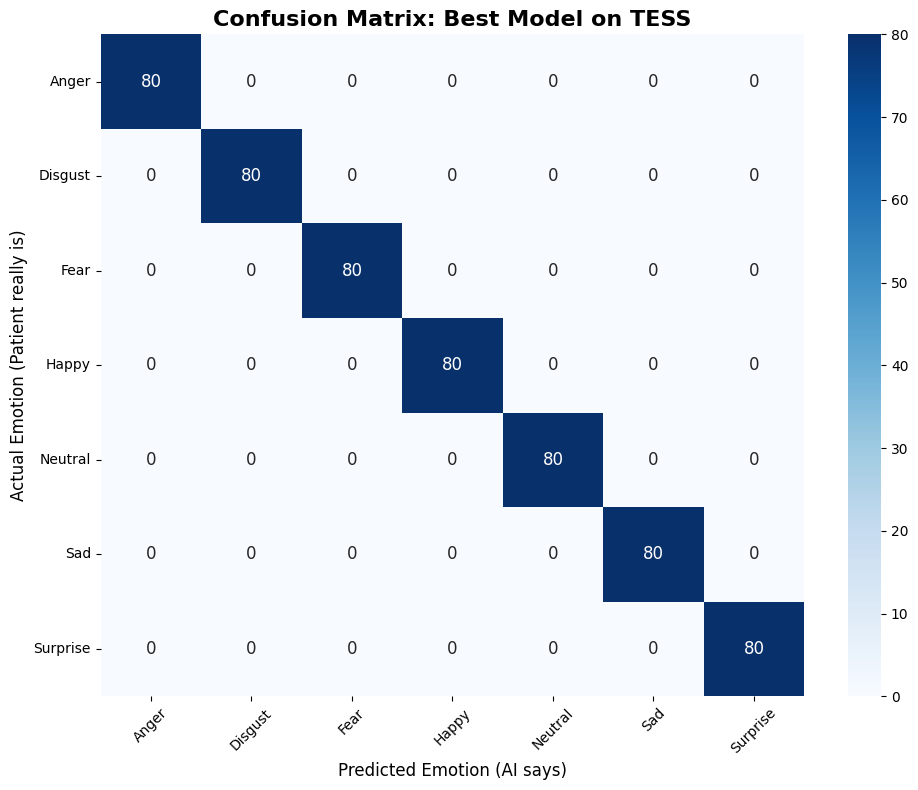


📋 CLINICAL CLASSIFICATION REPORT: TESS
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00        80
     Disgust       1.00      1.00      1.00        80
        Fear       1.00      1.00      1.00        80
       Happy       1.00      1.00      1.00        80
     Neutral       1.00      1.00      1.00        80
         Sad       1.00      1.00      1.00        80
    Surprise       1.00      1.00      1.00        80

    accuracy                           1.00       560
   macro avg       1.00      1.00      1.00       560
weighted avg       1.00      1.00      1.00       560

📊 Generating Final Report for: BAVED
🏆 Best Model Found: wav2vec2-base
⚙️ Config: LR=3e-05 | Batch Size=16
📈 Validation Accuracy: 0.8615

⏳ Loading Data and Model...


Loading weights:   0%|          | 0/215 [00:01<?, ?it/s]

🔮 Running Predictions on Test Set...


📸 Confusion Matrix saved to: /content/drive/MyDrive/Colab022Notebooks/GP/ModelExp/_Plots/BAVED_Confusion_Matrix.png


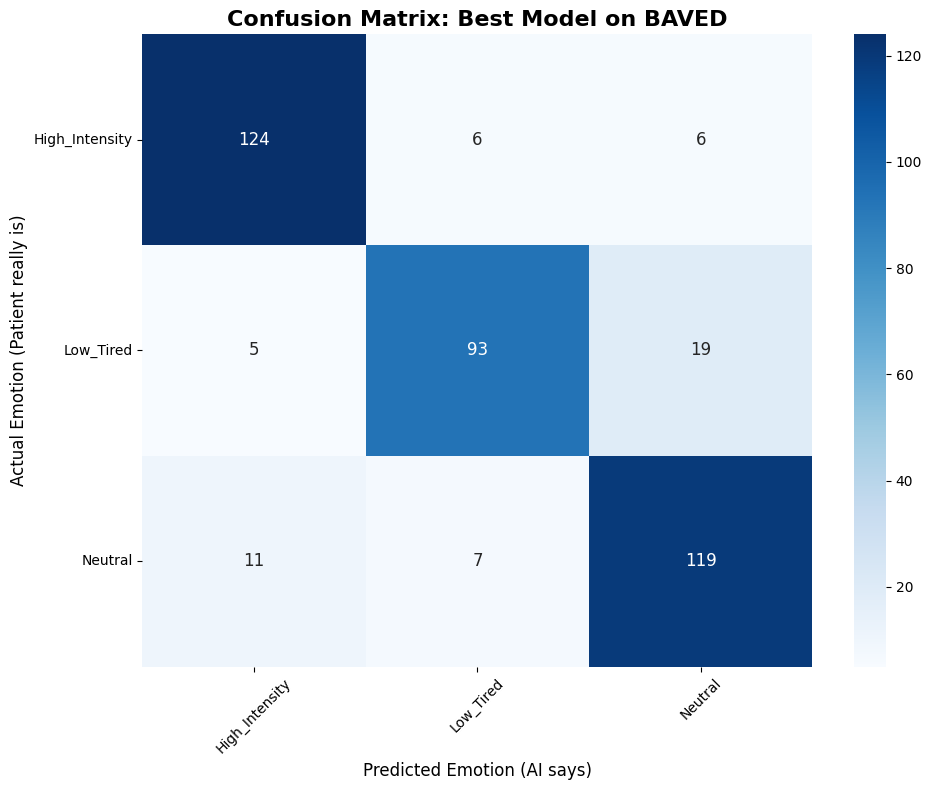


📋 CLINICAL CLASSIFICATION REPORT: BAVED
                precision    recall  f1-score   support

High_Intensity       0.89      0.91      0.90       136
     Low_Tired       0.88      0.79      0.83       117
       Neutral       0.83      0.87      0.85       137

      accuracy                           0.86       390
     macro avg       0.86      0.86      0.86       390
  weighted avg       0.86      0.86      0.86       390



In [ ]:
# ==========================================
# 2. select best model
# ==========================================
for TARGET_DATASET in DATASETS:

  print(f"📊 Generating Final Report for: {TARGET_DATASET}")
  master_results = pd.read_csv(csv_path)
  dataset_results = master_results[master_results['Dataset'] == TARGET_DATASET]
  best_run = dataset_results.sort_values(by='Accuracy', ascending=False).iloc[0]

  best_model_path = best_run['Model_Path']
  print(f"🏆 Best Model Found: {best_run['Model']}")
  print(f"⚙️ Config: LR={best_run['LR']} | Batch Size={best_run['Batch_Size']}")
  print(f"📈 Validation Accuracy: {best_run['Accuracy']:.4f}")

  # ==========================================
  # 3. Loading Data and Model
  # ==========================================
  print("\n⏳ Loading Data and Model...")
  dataset_path = arrow_save_dir / TARGET_DATASET
  label_path = arrow_save_dir / f"{TARGET_DATASET}_labels.json"

  # Loading test data (we only need test ignore training)
  encoded_test = load_from_disk(str(dataset_path))["test"]

  # Load emotion map
  with open(label_path, "r") as f:
      label2id = json.load(f)
  id2label = {int(v): k for k, v in label2id.items()}
  label_names = list(id2label.values())

  # Load the winner model
  model = AutoModelForAudioClassification.from_pretrained(best_model_path)

# Dummy Args
  training_args = TrainingArguments(
      output_dir = out_dir/"eval_temp",
       per_device_eval_batch_size=16,
      fp16=True,
      remove_unused_columns=False
  )

  # Collator
  from dataclasses import dataclass
  from typing import Union, List, Dict
  @dataclass
  class DataCollatorForAudio:
      processor: Wav2Vec2Processor
      padding: Union[bool, str] = True
      def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
          input_features = [{"input_values": feature["input_values"]} for feature in features]
          label_features = [feature["label"] for feature in features]
          batch = self.processor.pad(input_features, padding=self.padding, return_tensors="pt")
          batch["labels"] = torch.tensor(label_features)
          return batch

  dummy_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
  data_collator = DataCollatorForAudio(processor=dummy_processor)

  trainer = Trainer(
      model=model,
      args=training_args,
      data_collator=data_collator
  )

  # ==========================================
  # 4. (Predictions)
  # ==========================================
  print("🔮 Running Predictions on Test Set...")
  predictions_output = trainer.predict(encoded_test)
  y_pred = np.argmax(predictions_output.predictions, axis=1)
  y_true = predictions_output.label_ids

  # ==========================================
  # 5. Confusion Matrix
  # ==========================================
  cm = confusion_matrix(y_true, y_pred)

  plt.figure(figsize=(10, 8))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=label_names, yticklabels=label_names,
              annot_kws={"size": 12})
  plt.title(f'Confusion Matrix: Best Model on {TARGET_DATASET}', fontsize=16, fontweight='bold')
  plt.xlabel('Predicted Emotion (AI says)', fontsize=12)
  plt.ylabel('Actual Emotion (Patient really is)', fontsize=12)
  plt.xticks(rotation=45)
  plt.yticks(rotation=0)
  plt.tight_layout()

  # save the plot
  plot_path = out_dir /"_Plots"/f"{TARGET_DATASET}_Confusion_Matrix.png"
  plt.savefig(plot_path, dpi=300)
  print(f"📸 Confusion Matrix saved to: {plot_path}")
  plt.show()

  # ==========================================
  # 6. (Classification Report)
  # ==========================================
  print("\n" + "="*50)
  print(f"📋 CLINICAL CLASSIFICATION REPORT: {TARGET_DATASET}")
  print("="*50)
  report = classification_report(y_true, y_pred, target_names=label_names)
  print(report)

  # save classification report
  with open(out_dir /"_Classification_Reports" / f"{TARGET_DATASET}_Classification_Report.txt", "w") as f:
      f.write(report)